# Hermite approximations of various target functions

Let's start by loading necessary libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax 
from jax import numpy as jnp
from flows.types import *
import optax
from flows.utils import *
from flows.models.linear import Linear
from flows.utils import *
import matplotlib.pyplot as plt
from functools import partial
from flows.Bases import Hermite 
from flows.bases import *
import flax.linen as nn
import sys 
import math
import pickle 
from sklearn.linear_model import LinearRegression
from target_functions import *
jax.config.update("jax_enable_x64", True)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Computer Modern Roman'
fontsize_label = 18
fontsize_title = fontsize_label + 1
fontsize_legend = fontsize_label - 4
# size of the ticks 
plt.rcParams['xtick.labelsize'] = fontsize_label - 5
plt.rcParams['ytick.labelsize'] = fontsize_label - 5

print(f"available devices: {jax.devices()}")

available devices: [CpuDevice(id=0)]


Let's now define Hermite functions.

In [2]:
nmax = 20
n_basis = [nmax for _ in range(1)]
w_basis = [1 for _ in range(1)]
#weights for generating the basis on which we project
basis_r = Hermite.init_basis(n_basis, w_basis, nmax, orthotype=orthoType.ortho) # 

psi_o = partial(Hermite.batch_basis_values, basis_r)  

In [3]:
decay_list = ["algebraic", "superGaussian", "Gaussian", "tanh"]


In [4]:
# Let's start compute the best approximation of $f$ in the basis $\psi_{no}$

def compute_coeff(decay):
    if decay == "algebraic":
        x = jnp.linspace(-30.999, 30.999, 10000)
        full_f = full_f_algebraic
    elif decay == "superGaussian":
        x = jnp.linspace(-12.999, 12.999, 10000)
        full_f = full_f_super_Gaussian
    elif decay == "tanh":
        x = jnp.linspace(-12.999, 12.999, 10000)
        full_f = full_f_tanh
    y = x
    w = np.zeros_like(x)
    dx = np.diff(x)
    w[1:-1] = (dx[:-1] + dx[1:])/2
    w[0] = dx[0]/2
    w[-1] = dx[-1]/2
    x = x[:,None]

    y = x
    true_func = full_f(x,w)
    psi_ev = psi_o(y)
    weight = jnp.exp(-y[:,0]**2/2)
    psi_ev = jnp.einsum('jk,j->jk', psi_ev, weight)
    
    approx_coeffs = jnp.einsum('j,jk,j->k', true_func, psi_ev, w)
    return approx_coeffs

def l2_error(x, w, true_func, approx_func):
    
    error = jnp.sqrt(jnp.einsum('i,i->', (true_func - approx_func)**2, w))
    return error

def linf_error(x, w, true_func, approx_func):  
    error = jnp.max(jnp.abs(true_func - approx_func))
    return error
 
decay_list = ['algebraic', 'superGaussian', 'tanh']

# define the values of n 
n_values = np.arange(2,48,4)

for decay in decay_list:
    losses_l = []
    lossesinf_l = []
    size_basis = []
    approximating_func = lambda x, coeffs: jnp.einsum('k,jk,j->j', coeffs, psi_o(x), jnp.exp(-(x[:,0])**2/2))

    for n in n_values:
        nmax = n
        n_basis = [nmax for _ in range(1)]
        w_basis = [1 for _ in range(1)]
        # Note that when we project we need to multiply by the weights of the basis        
        basis_r = Hermite.init_basis(n_basis, w_basis, nmax, orthotype=orthoType.ortho) # 

        psi_o = partial(Hermite.batch_basis_values, basis_r)  
        if decay == "algebraic":
            x = jnp.linspace(-30.999, 30.999, 10000)
            full_f = full_f_algebraic
        elif decay == "superGaussian":
            x = jnp.linspace(-12.999, 12.999, 10000)
            full_f = full_f_super_Gaussian
        elif decay == "tanh":
            x = jnp.linspace(-12.999, 12.999, 10000)
            full_f = full_f_tanh
        y = x
        w = np.zeros_like(x)
        dx = np.diff(x)
        w[1:-1] = (dx[:-1] + dx[1:])/2
        w[0] = dx[0]/2
        w[-1] = dx[-1]/2
        x = x[:,None]

        true_func = full_f(x,w)
        coeffs = compute_coeff(decay)
        
        approximation = approximating_func(x, coeffs)
        loss_l = l2_error(x, w, true_func, approximation)
        lossinf_l = linf_error(x, w, true_func, approximation)
        losses_l.append(loss_l)
        lossesinf_l.append(lossinf_l)
        size_basis.append(n+1)
    np.savez(f"simulations_data/Hermite_{decay}.npz", size_basis=size_basis, losses_l=losses_l, lossesinf_l=lossesinf_l)


## Plotting convergence 

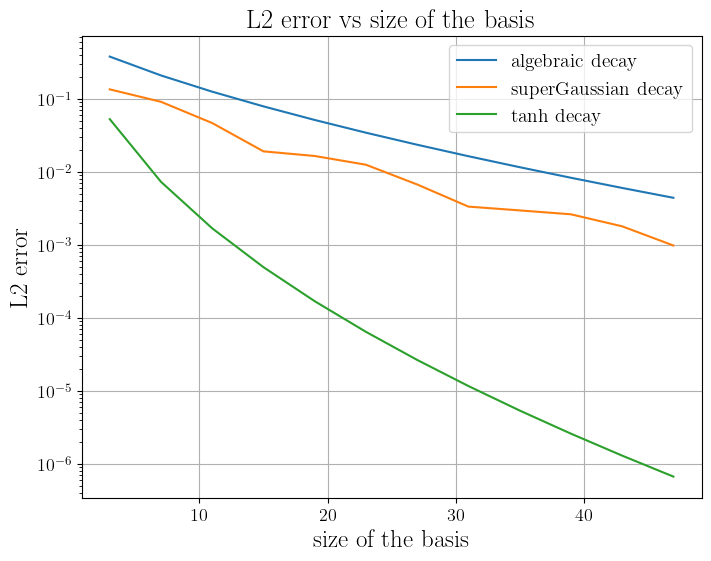

In [5]:
# load the data and plot the results
plt.figure(figsize=(8,6))
for decay in decay_list:
    data = np.load(f"simulations_data/Hermite_{decay}.npz")
    size_basis = data["size_basis"]
    losses_l = data["losses_l"]
    lossesinf_l = data["lossesinf_l"]
    plt.plot(size_basis, losses_l, label=f"{decay} decay")
plt.yscale("log")
plt.xlabel("size of the basis", fontsize=fontsize_label)
plt.ylabel("L2 error", fontsize=fontsize_label)
plt.title("L2 error vs size of the basis", fontsize=fontsize_title)
plt.legend(fontsize=fontsize_legend)
plt.grid()
plt.show()